<a href="https://colab.research.google.com/github/L1KASA/DLS/blob/main/part_2/hw_2_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание. Нейросетевая классификация текстов

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [ ]:
!pip install datasets

Импорт необходимых библиотек

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части.

In [ ]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [ ]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [ ]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [ ]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [ ]:
def evaluate(model) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна.

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие.

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты.
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет.
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная?
* Укажите, какая модель получилась оптимальной.

Желаем удачи!

## Базовая модель

In [ ]:
class BaseLM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max', rnn_type: str = 'rnn', num_layers: int = 1
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)

        if rnn_type == 'rnn':
            self.rnn = nn.RNN(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        elif rnn_type == 'gru':
            self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        elif rnn_type == 'lstm':
            self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        else:
            raise ValueError("rnn_type must be 'rnn', 'gru', or 'lstm'")

        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))
        prediction = self.projection(self.non_lin(output))

        return prediction

In [ ]:
all_results = {}

In [ ]:
def train_model(
    model_class,
    model_name,
    train_dataloader,
    eval_dataloader,
    word2ind,
    device,
    num_epoch=5,
    hidden_dim=256,
    dropout_rate=0.1,
    learning_rate=0.001
):
    eval_steps = len(train_dataloader) // 2

    losses_type = {}
    acc_type = {}

    for aggregation_type in ['max', 'mean']:
        print(f"\n{model_name} - {aggregation_type} aggregation")
        print(f"epochs={num_epoch}, hidden_dim={hidden_dim}, dropout={dropout_rate}, lr={learning_rate}")

        losses = []
        acc = []

        model = model_class(
            hidden_dim=hidden_dim,
            vocab_size=len(vocab),
            aggregation_type=aggregation_type,
            num_classes=4
        ).to(device)

        model.dropout = nn.Dropout(p=dropout_rate)

        criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        for epoch in range(num_epoch):
            epoch_losses = []
            model.train()

            for i, batch in enumerate(tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{num_epoch}')):
                optimizer.zero_grad()
                logits = model(batch['input_ids'])
                loss = criterion(logits, batch['label'])
                loss.backward()
                optimizer.step()

                epoch_losses.append(loss.item())

                if i % eval_steps == 0 and i > 0:
                    model.eval()
                    acc.append(evaluate(model))
                    model.train()

            avg_loss = sum(epoch_losses) / len(epoch_losses)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f}")

        losses_type[aggregation_type] = losses
        acc_type[aggregation_type] = acc

        print(f"Best accuracy: {max(acc) * 100:.2f}%")

    return losses_type, acc_type

In [ ]:
def plot_results(losses_type, acc_type, model_name):
    for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
        plt.plot(np.arange(len(losses_type[name])), losses_type[name], color=color, label=name)
    plt.title(f'{model_name} Losses')
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    for (name, values), color in zip(acc_type.items(), ['red', 'blue']):
        plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    plt.title(f'{model_name} Accuracy')
    plt.xlabel("step")
    plt.legend()
    plt.show()

## CharLM

In [ ]:
class CharLM(BaseLM):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
                 aggregation_type: str = 'max'):
        super().__init__(
            hidden_dim, vocab_size, num_classes, aggregation_type, rnn_type='rnn'
        )

## GruLM

In [ ]:
class GruLM(BaseLM):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
                 aggregation_type: str = 'max'):
        super().__init__(
            hidden_dim, vocab_size, num_classes, aggregation_type, rnn_type='gru'
        )

## LSTM

In [ ]:
class LstmLM(BaseLM):
  def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
               aggregation_type: str = 'max'):
      super().__init__(
          hidden_dim, vocab_size, num_classes, aggregation_type, rnn_type='lstm',
          )

## С двумя слоями

In [ ]:
class DeepRNN(BaseLM):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
                 aggregation_type: str = 'max'):
        super().__init__(hidden_dim, vocab_size, num_classes, aggregation_type,
                        rnn_type='rnn', num_layers=2)

In [ ]:
class DeepGRU(BaseLM):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
                 aggregation_type: str = 'max'):
        super().__init__(hidden_dim, vocab_size, num_classes, aggregation_type,
                        rnn_type='gru', num_layers=2)

In [ ]:
class DeepLSTM(BaseLM):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
                 aggregation_type: str = 'max'):
        super().__init__(hidden_dim, vocab_size, num_classes, aggregation_type,
                        rnn_type='lstm', num_layers=2)

## Модель, которая конкатенирует агрегацию со всех токенов и последний токен

In [ ]:
class ConcatLM(BaseLM):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
                 aggregation_type: str = 'max'):
        super().__init__(hidden_dim, vocab_size, num_classes, aggregation_type, rnn_type='rnn')
        self.concat_projection = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            aggregated = output.max(dim=1)[0]  # [batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            aggregated = output.mean(dim=1)  # [batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        last_token = output[:, -1, :]  # [batch_size, hidden_dim]

        combined = torch.cat([aggregated, last_token], dim=1)  # [batch_size, hidden_dim * 2]

        output = self.concat_projection(combined)  # [batch_size, hidden_dim]

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

## Сравнение архитектур


RNN - max aggregation
epochs=5, hidden_dim=256, dropout=0.1, lr=0.001


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.4015


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2778


...

Epoch 3 - Loss: 0.2166


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 4 - Loss: 0.1869


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 5 - Loss: 0.1622
Best accuracy: 90.72%


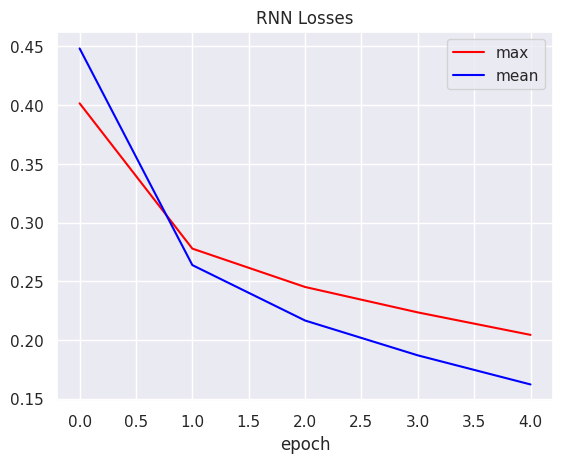

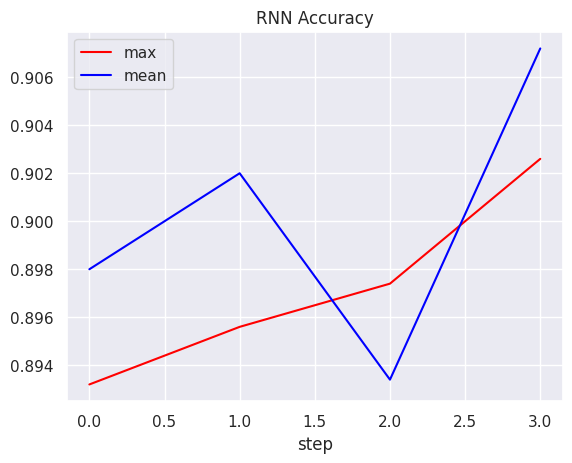


GRU - max aggregation
epochs=5, hidden_dim=256, dropout=0.1, lr=0.001


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.3527


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2165


...

Epoch 3 - Loss: 0.1437


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 4 - Loss: 0.0967


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 5 - Loss: 0.0701
Best accuracy: 91.18%


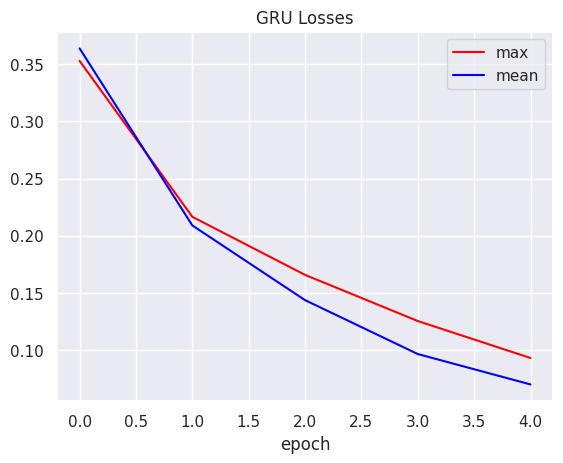

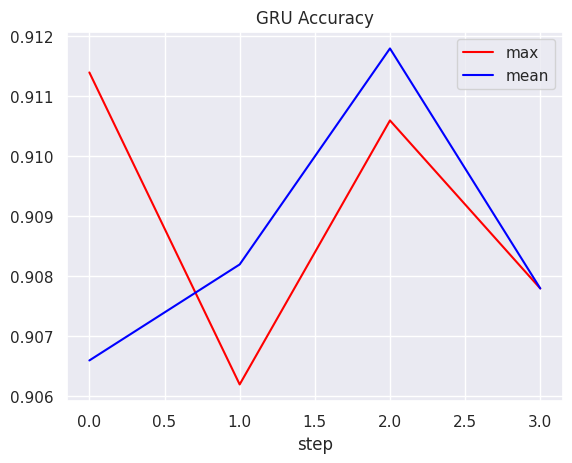


LSTM - max aggregation
epochs=5, hidden_dim=256, dropout=0.1, lr=0.001


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.3476


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2103


...

Epoch 3 - Loss: 0.1408


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 4 - Loss: 0.0872


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 5 - Loss: 0.0549
Best accuracy: 91.22%


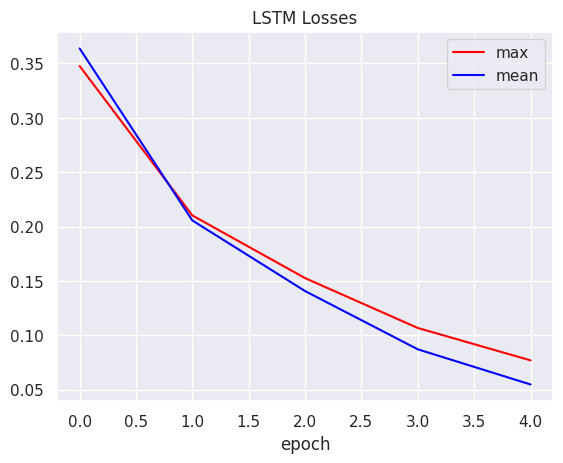

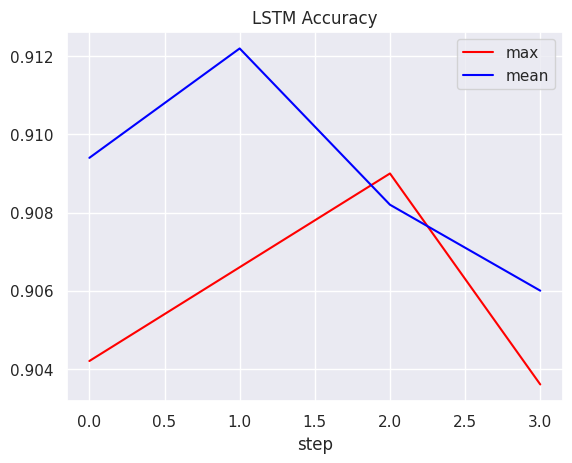


DeepRNN - max aggregation
epochs=5, hidden_dim=256, dropout=0.1, lr=0.001


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.4114


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2676


...

Epoch 3 - Loss: 0.2203


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 4 - Loss: 0.1897


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 5 - Loss: 0.1658
Best accuracy: 90.62%


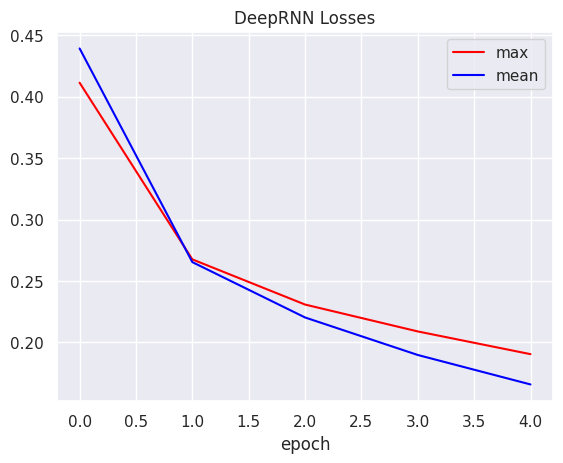

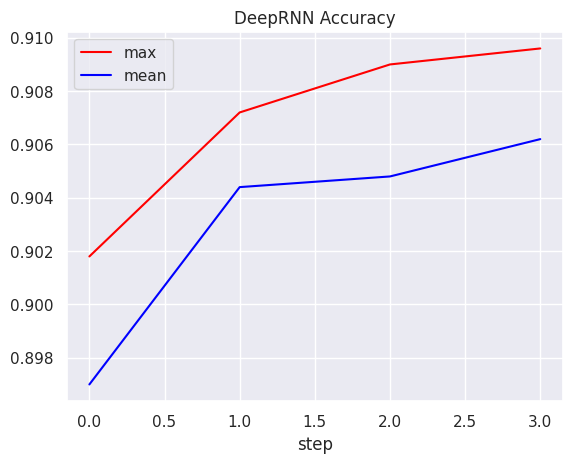


DeepGRU - max aggregation
epochs=5, hidden_dim=256, dropout=0.1, lr=0.001


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.3632


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2176


...

Epoch 3 - Loss: 0.1527


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 4 - Loss: 0.1067


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 5 - Loss: 0.0778
Best accuracy: 91.60%


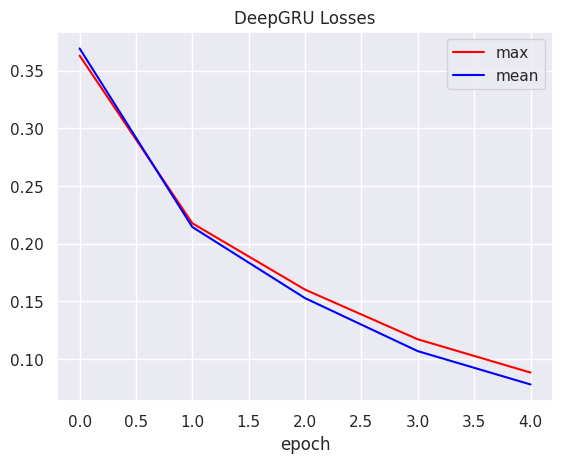

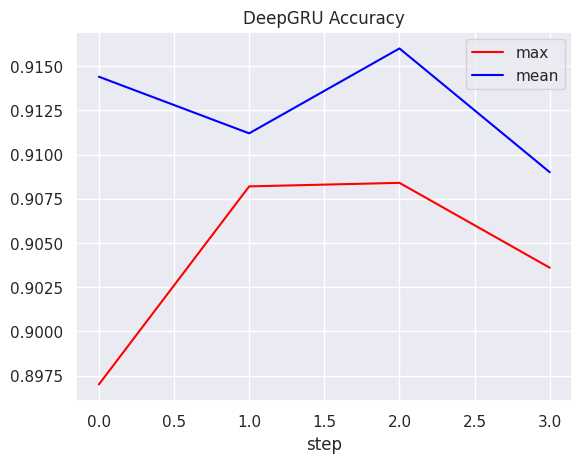


DeepLSTM - max aggregation
epochs=5, hidden_dim=256, dropout=0.1, lr=0.001


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.3594


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2109


...

Epoch 3 - Loss: 0.1476


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 4 - Loss: 0.0936


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 5 - Loss: 0.0608
Best accuracy: 91.26%


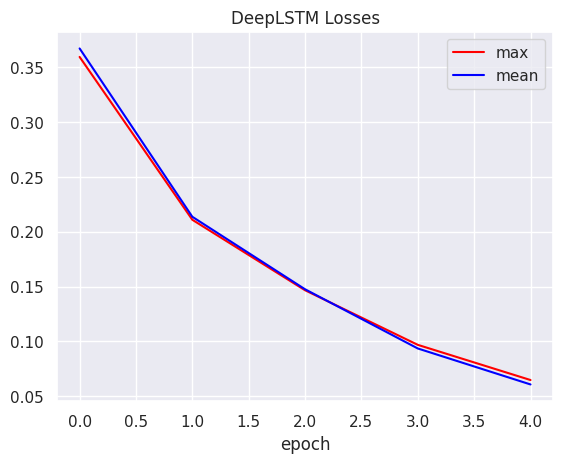

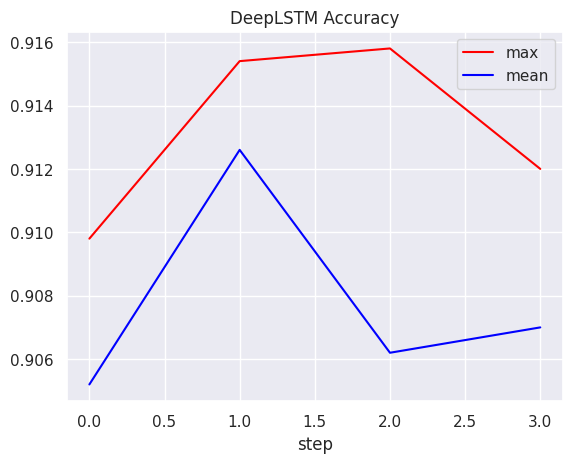


ConcatAgg - max aggregation
epochs=5, hidden_dim=256, dropout=0.1, lr=0.001


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.4767


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2919


...

Epoch 3 - Loss: 0.2867


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 4 - Loss: 0.2809


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 5 - Loss: 0.2637
Best accuracy: 89.10%


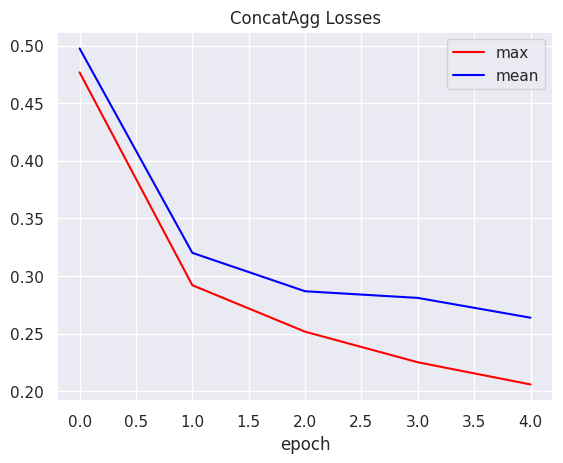

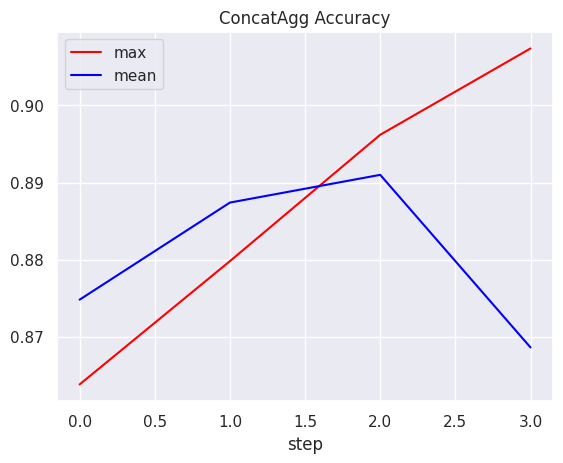


Лучшая архитектура: DeepGRU (mean) - 91.60%


In [ ]:
models = {
    'RNN': CharLM,
    'GRU': GruLM,
    'LSTM': LstmLM,
    'DeepRNN': DeepRNN,
    'DeepGRU': DeepGRU,
    'DeepLSTM': DeepLSTM,
    'ConcatAgg': ConcatLM
}

for name, model_class in models.items():
    losses, acc = train_model(model_class, name, train_dataloader, eval_dataloader,
                              word2ind, device, num_epoch=5)
    all_results[name] = {'losses': losses, 'accuracies': acc}
    plot_results(losses, acc, name)

best_score = 0
best_name = ""
best_agg = ""

for name, res in all_results.items():
    for agg in ['max', 'mean']:
        score = max(res['accuracies'][agg]) * 100
        if score > best_score:
            best_score = score
            best_name = name
            best_agg = agg

print(f"\nЛучшая архитектура: {best_name} ({best_agg}) - {best_score:.2f}%")

best_model_class = models[best_name]

## Подбор гиперпараметров для лучшей архитектуры


DeepGRU_10epochs - max aggregation
epochs=10, hidden_dim=256, dropout=0.1, lr=0.001


Epoch 1/10:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.3616


Epoch 2/10:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2193


...

Epoch 8 - Loss: 0.0455


Epoch 9/10:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 9 - Loss: 0.0418


Epoch 10/10:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 10 - Loss: 0.0398
Best accuracy: 91.08%


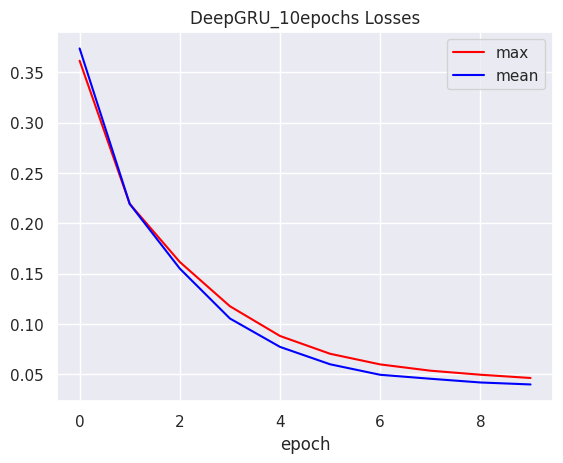

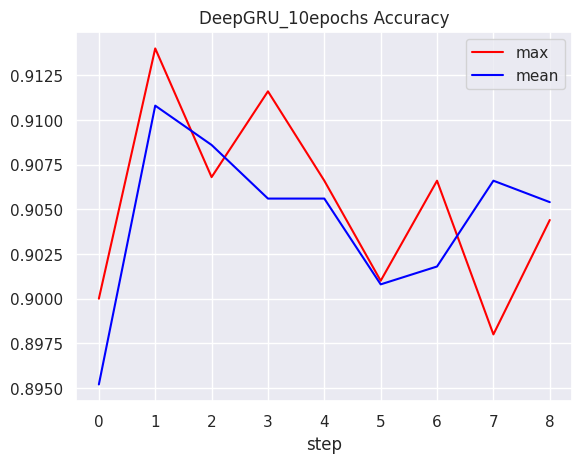


DeepGRU_15epochs - max aggregation
epochs=15, hidden_dim=256, dropout=0.1, lr=0.001


Epoch 1/15:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.3649


Epoch 2/15:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2180


...

Epoch 13 - Loss: 0.0396


Epoch 14/15:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 14 - Loss: 0.0399


Epoch 15/15:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 15 - Loss: 0.0370
Best accuracy: 91.22%


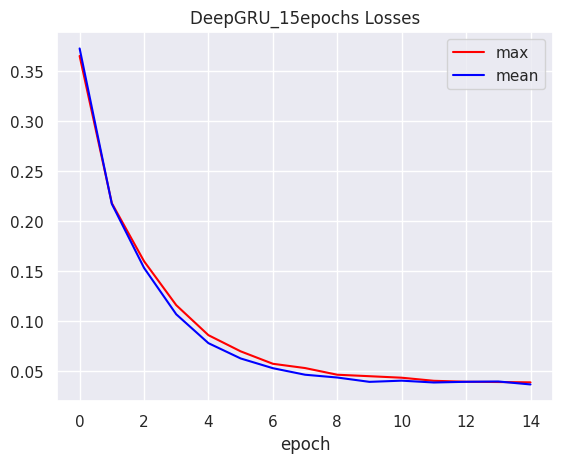

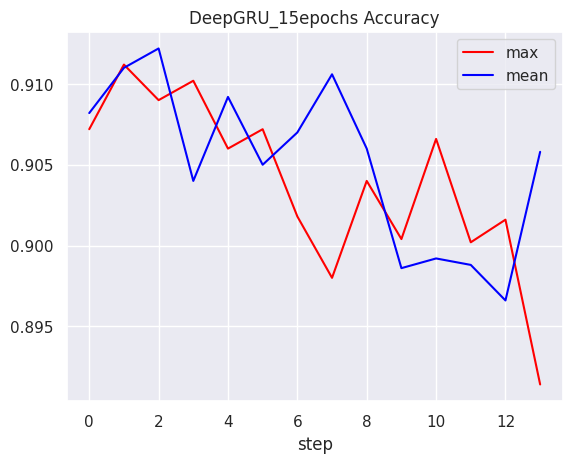


DeepGRU_hidden512 - max aggregation
epochs=5, hidden_dim=512, dropout=0.1, lr=0.001


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.3472


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2114


...

Epoch 3 - Loss: 0.1521


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 4 - Loss: 0.1139


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 5 - Loss: 0.0897
Best accuracy: 91.38%


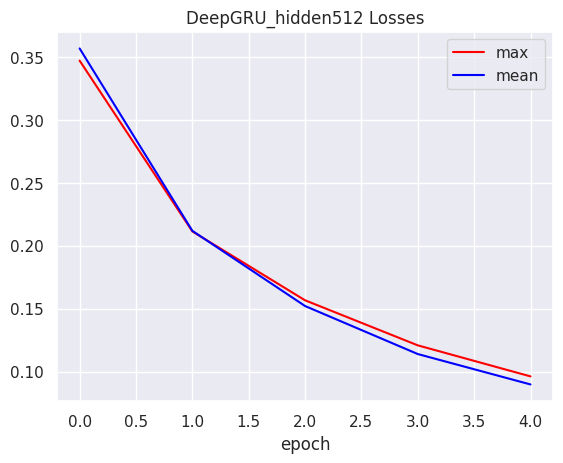

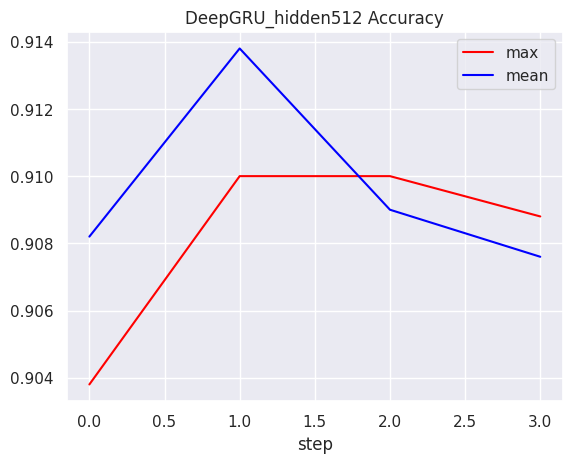


DeepGRU_dropout0.3 - max aggregation
epochs=5, hidden_dim=256, dropout=0.3, lr=0.001


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.3657


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.2230


...

Epoch 3 - Loss: 0.1595


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 4 - Loss: 0.1140


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 5 - Loss: 0.0831
Best accuracy: 91.50%


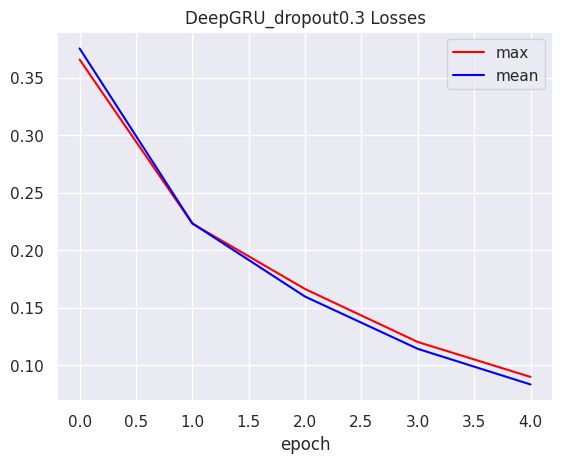

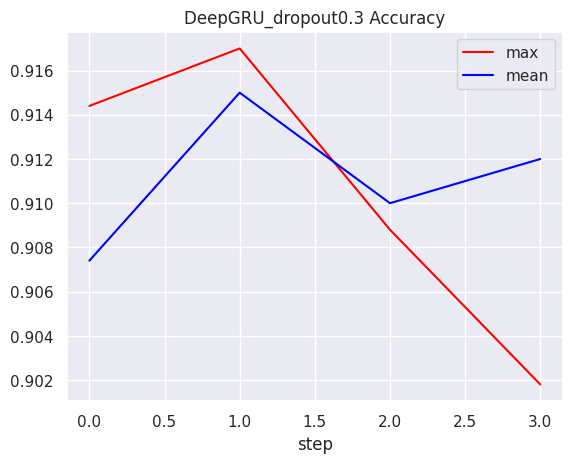

In [ ]:
hyperparams = [
    (10, 256, 0.1, 0.001, "10epochs"),
    (15, 256, 0.1, 0.001, "15epochs"),
    (5, 512, 0.1, 0.001, "hidden512"),
    (5, 256, 0.3, 0.001, "dropout0.3")
]

for epochs, hdim, dropout, lr, desc in hyperparams:
    name = f"{best_name}_{desc}"
    losses, acc = train_model(best_model_class, name, train_dataloader, eval_dataloader,
                              word2ind, device, num_epoch=epochs, hidden_dim=hdim,
                              dropout_rate=dropout, learning_rate=lr)
    all_results[name] = {'losses': losses, 'accuracies': acc}
    plot_results(losses, acc, name)

## Результирующая статистика

In [ ]:
final_results = []
for name, res in all_results.items():
    for agg in ['max', 'mean']:
        score = max(res['accuracies'][agg]) * 100
        final_results.append((name, agg, score))

final_results.sort(key=lambda x: x[2], reverse=True)

print("\nТоп-5 моделей:")
for i, (name, agg, score) in enumerate(final_results[:5], 1):
    print(f"{i}. {name} ({agg}): {score:.2f}%")

best = final_results[0]
print(f"\nЛучшая модель: {best[0]} ({best[1]})")
print(f"   Accuracy: {best[2]:.2f}%")


Топ-5 моделей:
1. DeepGRU_dropout0.3 (max): 91.70%
2. DeepGRU (mean): 91.60%
3. DeepLSTM (max): 91.58%
4. DeepGRU_dropout0.3 (mean): 91.50%
5. DeepGRU_10epochs (max): 91.40%

Лучшая модель: DeepGRU_dropout0.3 (max)
   Accuracy: 91.70%


## Вывод

### Анализ сходимости моделей
По графикам loss и accuracy можно сделать следующие наблюдения:

* GRU и DeepGRU показали самую быструю и стабильную сходимость. Loss снижался интенсивно в первые 2-3 эпохи, но далее просто остался на одном уровне. Accuracy стабилизировалась уже к 3-й эпохе. Колебания качества между оценками были минимальными - в пределах 0.2-0.3%, что говорит об устойчивом обучении.

* RNN и DeepRNN сходились медленнее. Loss снижался плавно на протяжении всех 5 эпох. Accuracy имела небольшие колебания - до 0.5% между оценками. Это указывает на то, что RNN требует больше времени для стабилизации.

* LSTM и DeepLSTM показали промежуточный результат. Сходимость была плавной, но более быстрой, чем у RNN. Колебания accuracy составляли около 0.3-0.4%.

* ConcatAgg стала исключением - ее сходимость была нестабильной. Loss снижался медленно, accuracy колебалась существенно (до 1-1.5%).

* DeepGRU с dropout=0.3 показала самую стабильную сходимость. Loss снижался быстро и плавно, accuracy практически не колебалась после 3-й эпохи. Увеличенный dropout помог сделать модель более устойчивой.

### Какие эксперименты принесли улучшение
#### Архитектурные улучшения (относительно 90.72% у RNN):

* GRU дал прирост до 0.88% (91.18%)
* LSTM дал прирост до 0.50% (91.22%)
* DeepGRU дал прирост 0.88% (91.60%)
* DeepLSTM дал прирост 0.86% (91.58%)

#### Гиперпараметры:
* Увеличение dropout до 0.3 дало прирост 0.10% относительно базовой DeepGRU

### Какие эксперименты не дали улучшения
#### Архитектурные:
* DeepRNN не дал стабильного прироста
* ConcatAgg ухудшил качество, особенно при mean aggregation

#### Гиперпараметры:
* Увеличение эпох до 10 и 15 не улучшило качество
* Увеличение hidden_dim до 512 не дало прироста


### Оптимальная модель
Лучшей моделью оказалась DeepGRU с dropout=0.3 и max aggregation. Она показала accuracy 91.70%, что является максимальным результатом среди всех экспериментов.

Причины, по которой модель стала лучшей:

* Двухслойная архитектура GRU позволила лучше улавливать зависимости в данных
* Увеличенный dropout (0.3) помог справиться с небольшим переобучением, которое присутствовало в базовой версии
* Max aggregation оказалась более эффективной для этой архитектуры, чем mean
* Модель обучалась стабильно, быстро сходилась и показала минимальные колебания качества на валидации.